# 04 — Government Fiscal Impact

Scale individual-level retirement outcomes to a DoD aggregate cost
comparison under High-Three and BRS.

**Government cost definition (actuarial cost basis):**  
The government’s retirement cost per person is the NPV of its actual
cash outlays — pension payments plus TSP contributions made during
service. Both are valued at the separation date using the 5% discount
rate and expressed in constant 2026 dollars (matching 03a). TSP investment returns are earned inside the member’s account by
financial markets, not by DoD, so they are excluded from DoD’s cost.

| Component | High-Three | BRS |
|---|---|---|
| Pension NPV | 2.5% × YOS × High-3 base | 2.0% × YOS × High-3 base |
| Govt TSP cost | None (0% govt contribution) | PV of 5% contributions at 5% |

`GovtTSP_PV` = PV at separation of government TSP
contributions (1% automatic in YOS 1–2; 1% + 4% match = 5%
from YOS 3), with basic pay grown at 2.75%/yr, each
contribution compounded forward at 5% to the separation
date, then deflated to 2026 dollars. This is the actuarial
“normal cost” of TSP contributions, consistent with how
pension NPV is discounted.

The comparison table below quantifies how this choice affects the result.

**Scenario weighting:**  
P(sep at YOS y) = Survival(y−1) − Survival(y) from the DoD actuarial
table. Non-modeled YOS values are binned to the nearest modeled
scenario (midpoint assignment). Weights sum to 1 per profile.

**Inputs:** `deterministic_results.csv`, `withdrawal_rates.csv`,
`pay_profiles.csv`  
**Outputs:** `data/processed/fiscal_results.csv`,
`data/processed/scenario_weights.csv`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../src")))

PROCESSED = Path("../data/processed")

## Constants and data

In [2]:
YOS_SCENARIOS = list(range(4, 41, 2))  # 4-40, step 2
PROFILE_SCENARIOS = {
    "Officer": YOS_SCENARIOS,
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": YOS_SCENARIOS,
}

DISCOUNT_RATE = 0.05      # nominal NPV rate (matches 03a/03b)
PAY_GROWTH = 0.0275       # pay raises track COLA (matches 03a)

# Approximate annual active-component accessions.
# Source: DoD FY2024 Population Representation report.
# Display order for cross-profile tables and charts
PROFILE_ORDER = [
    "Enlisted", "PriorEnlistedOfficer", "Officer"
]

OFFICER_ACCESSIONS = 18_000
ENLISTED_ACCESSIONS = 140_000

det = pd.read_csv(PROCESSED / "deterministic_results.csv")
wr = pd.read_csv(PROCESSED / "withdrawal_rates.csv")
pay = pd.read_csv(PROCESSED / "pay_profiles.csv")

print(f"Scenarios loaded:           {len(det)}")
print(
    f"Withdrawal table YOS range: "
    f"{wr['YOS'].min()}–{wr['YOS'].max()}"
)
print(f"Pay profile rows:           {len(pay)}")

Scenarios loaded:           52
Withdrawal table YOS range: 1–40
Pay profile rows:           110


## Government cost per separating member

For each scenario, isolate what the **government** pays
(constant 2026 \$):

- **H3_GovtCost** = H3PensionNPV — pension only; no TSP
- **GovtTSP_PV** = PV at separation of government TSP
  contributions (1% in YOS 1–2, 5% from YOS 3, on pay grown
  at 2.75%/yr), compounded forward to the separation date at
  5% and deflated to 2026 dollars; computed from
  `pay_profiles.csv`
- **BRS_GovtCost** = BRSPensionNPV + GovtTSP_PV
- **DoD_Savings** = H3_GovtCost − BRS_GovtCost
  (positive = BRS costs less for DoD)

For members separating before 20 YOS, no pension vests under
either system. H3_GovtCost = 0; BRS still incurs GovtTSP_PV,
so DoD_Savings is negative for all pre-retirement separations.

A comparison cell shows the magnitude of the actuarial vs.
entitlement TSP values for reference.

In [3]:
from tsp_calcs import brs_govt_rate  # noqa: E402


def govt_tsp_actuarial(pay_df, profile, sep_yos):
    """
    PV at separation of govt TSP contributions, 2026 $.

    Pay grows at PAY_GROWTH. Each year's government
    contribution (brs_govt_rate x nominal annual pay: 1%
    in YOS 1-2, 5% from YOS 3) is compounded forward to
    the separation date at DISCOUNT_RATE, then deflated
    to 2026 dollars - matching the reference date,
    discount rate, and units used for pension NPV.
    """
    career = pay_df.query(
        "Profile == @profile and YOS <= @sep_yos"
    ).set_index("YOS")["MonthlyPay"]
    total = 0.0
    for yos, monthly_pay in career.items():
        nom = monthly_pay * (1 + PAY_GROWTH) ** (yos - 1)
        contrib = nom * 12 * brs_govt_rate(yos)
        years = sep_yos - yos
        total += contrib * (1 + DISCOUNT_RATE) ** years
    return total / (1 + PAY_GROWTH) ** sep_yos


fiscal = det.copy()
fiscal["GovtTSP_PV"] = [
    govt_tsp_actuarial(pay, r["Profile"], r["SepYOS"])
    for _, r in fiscal.iterrows()
]
fiscal["H3_GovtCost"] = fiscal["H3PensionNPV"]
fiscal["BRS_GovtCost"] = (
    fiscal["BRSPensionNPV"] + fiscal["GovtTSP_PV"]
)
fiscal["DoD_Savings"] = (
    fiscal["H3_GovtCost"] - fiscal["BRS_GovtCost"]
)

print(
    "Actuarial vs. entitlement TSP cost"
    " (Officer, 2026 $ thousands):"
)
print(
    f"  {'SepYOS':>8} {'Actuarial (5%)':>16}"
    f" {'Entitlement (mkt)':>19} {'Ratio':>7}"
)
print("  " + "-" * 54)
for _, row in fiscal[
    fiscal["Profile"] == "Officer"
].iterrows():
    act = row["GovtTSP_PV"] / 1000
    ent = (
        row["BRS_TSP_PV"] - row["H3TSP_PV"]
    ) / 1000
    ratio = ent / act if act > 0 else float("nan")
    print(
        f"  {int(row['SepYOS']):>8d}"
        f" {'$' + format(act, ',.1f'):>16}"
        f" {'$' + format(ent, ',.1f'):>19}"
        f" {ratio:>7.2f}x"
    )

Actuarial vs. entitlement TSP cost (Officer, 2026 $ thousands):
    SepYOS   Actuarial (5%)   Entitlement (mkt)   Ratio
  ------------------------------------------------------
         4             $9.2               $24.4    2.64x
         6            $18.6               $46.9    2.52x
         8            $28.8               $69.6    2.42x
        10            $40.4               $93.7    2.32x
        12            $53.6              $119.4    2.23x
        14            $67.8              $145.4    2.15x
        16            $83.5              $172.6    2.07x
        18           $100.9              $200.9    1.99x
        20           $119.4              $229.5    1.92x
        22           $140.1              $260.0    1.86x
        24           $163.1              $292.5    1.79x
        26           $187.9              $326.0    1.74x
        28           $215.1              $361.5    1.68x
        30           $244.8              $398.6    1.63x
        32           $278

## Government cost by system and YOS

Note that the Prior-Enlisted Officer bars overtake the Officer
bars at the longest careers (~38–40 YOS). This is an age effect,
not a pay effect: at equal YOS the PEO is four years younger at
separation (entry age 18 vs 22) and collects the pension ~3 more
expected years, while the basic-pay cap compresses the two
profiles' High-3 bases together late in a career (the
annual-pension gap shrinks from ~28% at 24 YOS to ~3% at 40).
Pension cost is annual amount × years collected, so the longer
payment window wins once the pay gap closes. The same trade
explains why the Officer cost peaks near 36 YOS and dips slightly
by 40: each extra year of service adds little to a capped pension
but removes a full year of collection.


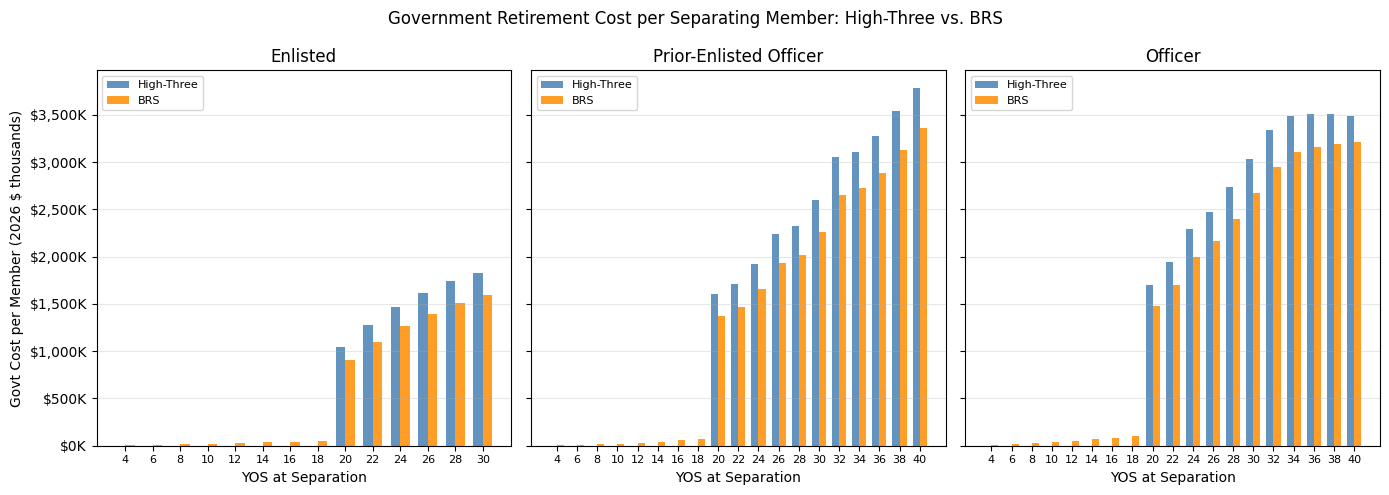

In [4]:
profile_labels = {
    "Enlisted": "Enlisted",
    "PriorEnlistedOfficer": "Prior-Enlisted Officer",
    "Officer": "Officer",
}

fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

bar_w = 0.35
for ax, (profile, label) in zip(
    axes, profile_labels.items()
):
    sub = fiscal[fiscal["Profile"] == profile].copy()
    x = np.arange(len(sub))

    ax.bar(
        x - bar_w / 2,
        sub["H3_GovtCost"] / 1000,
        width=bar_w,
        label="High-Three",
        color="steelblue",
        alpha=0.85,
    )
    ax.bar(
        x + bar_w / 2,
        sub["BRS_GovtCost"] / 1000,
        width=bar_w,
        label="BRS",
        color="darkorange",
        alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        sub["SepYOS"].astype(str), fontsize=8
    )
    ax.set_xlabel("YOS at Separation")
    ax.set_title(label)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda v, _: f"${v:,.0f}K"
        )
    )
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel(
    "Govt Cost per Member (2026 $ thousands)"
)
fig.suptitle(
    "Government Retirement Cost per Separating Member"
    ": High-Three vs. BRS",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## DoD savings per member by YOS

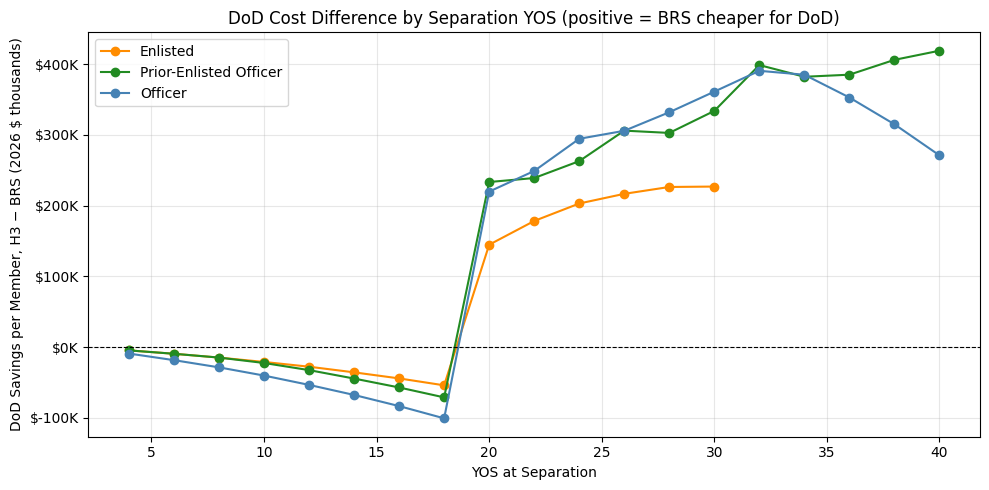

In [5]:
profile_colors = {
    "Enlisted": "darkorange",
    "PriorEnlistedOfficer": "forestgreen",
    "Officer": "steelblue",
}

fig, ax = plt.subplots(figsize=(10, 5))

for profile, color in profile_colors.items():
    sub = fiscal[fiscal["Profile"] == profile]
    ax.plot(
        sub["SepYOS"],
        sub["DoD_Savings"] / 1000,
        marker="o",
        label=profile_labels[profile],
        color=color,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("YOS at Separation")
ax.set_ylabel(
    "DoD Savings per Member, H3 − BRS (2026 $ thousands)"
)
ax.set_title(
    "DoD Cost Difference by Separation YOS"
    " (positive = BRS cheaper for DoD)"
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:,.0f}K")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Separation probability weights

The probability that a random entrant separates at each YOS comes
from the DoD actuarial withdrawal and survival tables:

P(sep at YOS y) = Survival(y−1) − Survival(y), where Survival(0) = 1

Since the model covers a discrete 2-year scenario grid, each
possible YOS (1–40) is assigned to the nearest modeled scenario by absolute
distance (ties go to the lower scenario). Weights sum to 1.

**PriorEnlistedOfficer:** officer withdrawal rates are applied for
the full career. Prior-enlisted officers are a self-selected subgroup
likely to exhibit officer career patterns after commissioning.

In [6]:
def sep_probs_by_yos(wr_df, surv_col):
    """
    Separation probability at each YOS 1–40.

    Returns
    -------
    dict  {yos (int): probability (float)}
    """
    probs = {}
    surv_prev = 1.0
    for _, row in wr_df.iterrows():
        yos = int(row["YOS"])
        surv = float(row[surv_col])
        probs[yos] = surv_prev - surv
        surv_prev = surv
    return probs


def bin_to_scenarios(probs, scenarios):
    """
    Aggregate per-YOS probabilities to modeled scenarios.

    Each YOS is assigned to the nearest scenario (ties
    go to the lower value).

    Returns
    -------
    pd.Series  indexed by scenario YOS, summing to ≈1
    """
    scenarios = sorted(scenarios)
    weights = {s: 0.0 for s in scenarios}
    for yos, prob in probs.items():
        dists = [abs(yos - s) for s in scenarios]
        nearest = scenarios[dists.index(min(dists))]
        weights[nearest] += prob
    return pd.Series(weights, name="Weight")


surv_col_map = {
    "Enlisted": "EnlistedSurvival",
    "PriorEnlistedOfficer": "OfficerSurvival",
    "Officer": "OfficerSurvival",
}

scenario_weights = {}
for profile, surv_col in surv_col_map.items():
    probs = sep_probs_by_yos(wr, surv_col)
    scenarios = PROFILE_SCENARIOS[profile]
    scenario_weights[profile] = bin_to_scenarios(
        probs, scenarios
    )

print(
    "Scenario weights"
    " (P(separation at modeled YOS bin)):"
)
for profile, w in scenario_weights.items():
    print(f"\n{profile}  [sum={w.sum():.4f}]:")
    for yos, wt in w.items():
        print(f"  YOS {yos:2d}: {wt:.4f}")

Scenario weights (P(separation at modeled YOS bin)):

Enlisted  [sum=1.0000]:
  YOS  4: 0.5256
  YOS  6: 0.1234
  YOS  8: 0.0764
  YOS 10: 0.0372
  YOS 12: 0.0218
  YOS 14: 0.0201
  YOS 16: 0.0059
  YOS 18: 0.0021
  YOS 20: 0.1091
  YOS 22: 0.0312
  YOS 24: 0.0244
  YOS 26: 0.0125
  YOS 28: 0.0038
  YOS 30: 0.0066

PriorEnlistedOfficer  [sum=1.0000]:
  YOS  4: 0.1980
  YOS  6: 0.1189
  YOS  8: 0.0993
  YOS 10: 0.0800
  YOS 12: 0.0529
  YOS 14: 0.0234
  YOS 16: 0.0113
  YOS 18: 0.0046
  YOS 20: 0.1698
  YOS 22: 0.0638
  YOS 24: 0.0498
  YOS 26: 0.0396
  YOS 28: 0.0291
  YOS 30: 0.0344
  YOS 32: 0.0101
  YOS 34: 0.0069
  YOS 36: 0.0038
  YOS 38: 0.0024
  YOS 40: 0.0019

Officer  [sum=1.0000]:
  YOS  4: 0.1980
  YOS  6: 0.1189
  YOS  8: 0.0993
  YOS 10: 0.0800
  YOS 12: 0.0529
  YOS 14: 0.0234
  YOS 16: 0.0113
  YOS 18: 0.0046
  YOS 20: 0.1698
  YOS 22: 0.0638
  YOS 24: 0.0498
  YOS 26: 0.0396
  YOS 28: 0.0291
  YOS 30: 0.0344
  YOS 32: 0.0101
  YOS 34: 0.0069
  YOS 36: 0.0038
  YOS 38: 0

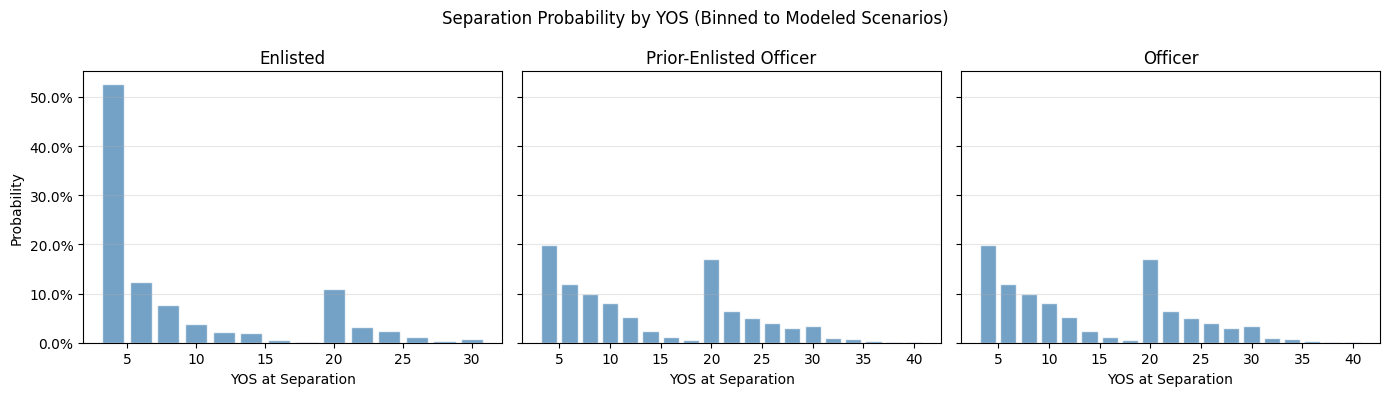

In [7]:
fig, axes = plt.subplots(
    1, 3, figsize=(14, 4), sharey=True
)

for ax, (profile, label) in zip(
    axes, profile_labels.items()
):
    w = scenario_weights[profile]
    ax.bar(
        w.index,
        w.values,
        width=1.6,
        color="steelblue",
        alpha=0.75,
        edgecolor="white",
    )
    ax.set_xlabel("YOS at Separation")
    ax.set_title(label)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.1%}")
    )
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Probability")
fig.suptitle(
    "Separation Probability by YOS"
    " (Binned to Modeled Scenarios)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Expected government cost per entering service member

Multiplying each scenario's government cost by its separation
probability and summing gives the expected cost per entrant — the
actuarial present value of retirement obligations for a member
entering service today, before their eventual career length is known.

Because ~59% of officers and ~81% of enlisted separate before
20 YOS, the TSP costs paid to early separatees under BRS accumulate
across a large population. Whether that cost exceeds the pension
savings for career retirees depends on the full distribution.

In [8]:
records = []
for profile in PROFILE_ORDER:
    w = scenario_weights[profile]
    sub = (
        fiscal[fiscal["Profile"] == profile]
        .set_index("SepYOS")
    )
    h3_exp = (
        w * sub.reindex(w.index)["H3_GovtCost"]
    ).sum()
    brs_exp = (
        w * sub.reindex(w.index)["BRS_GovtCost"]
    ).sum()
    tsp_exp = (
        w * sub.reindex(w.index)["GovtTSP_PV"]
    ).sum()
    brs_pen_exp = (
        w * sub.reindex(w.index)["BRSPensionNPV"]
    ).sum()
    records.append({
        "Profile": profile,
        "H3_Expected": h3_exp,
        "BRS_Expected": brs_exp,
        "BRS_PensionExp": brs_pen_exp,
        "BRS_TSPExp": tsp_exp,
        "Savings_PerEntrant": h3_exp - brs_exp,
        "Savings_Pct": (
            (h3_exp - brs_exp) / h3_exp
            if h3_exp > 0 else float("nan")
        ),
    })

expected = pd.DataFrame(records)

W = 13
print(
    "Expected government cost per entrant (2026 $ thousands):"
)
print(
    f"  {'Profile':30} {'H3':>{W}}"
    f" {'BRS Pension':>{W}} {'BRS TSP':>{W}}"
    f" {'BRS Total':>{W}} {'Savings':>{W}}"
)
print("  " + "-" * (35 + W * 5))
for _, row in expected.iterrows():
    sign = "+" if row["Savings_PerEntrant"] >= 0 else "-"
    sv_k = row["Savings_PerEntrant"] / 1000
    sv_str = sign + "$" + format(abs(sv_k), ",.1f")
    print(
        f"  {row['Profile']:30}"
        f" {'$' + format(row['H3_Expected'] / 1000, ',.1f'):>{W}}"
        f" {'$' + format(row['BRS_PensionExp'] / 1000, ',.1f'):>{W}}"
        f" {'$' + format(row['BRS_TSPExp'] / 1000, ',.1f'):>{W}}"
        f" {'$' + format(row['BRS_Expected'] / 1000, ',.1f'):>{W}}"
        f" {sv_str:>{W}}"
    )

Expected government cost per entrant (2026 $ thousands):
  Profile                                   H3   BRS Pension       BRS TSP     BRS Total       Savings
  ----------------------------------------------------------------------------------------------------
  Enlisted                              $228.8        $183.1         $21.7        $204.8        +$24.1
  PriorEnlistedOfficer                  $802.6        $642.1         $59.3        $701.4       +$101.2
  Officer                               $893.9        $715.2         $83.4        $798.6        +$95.3


### Cost component breakdown

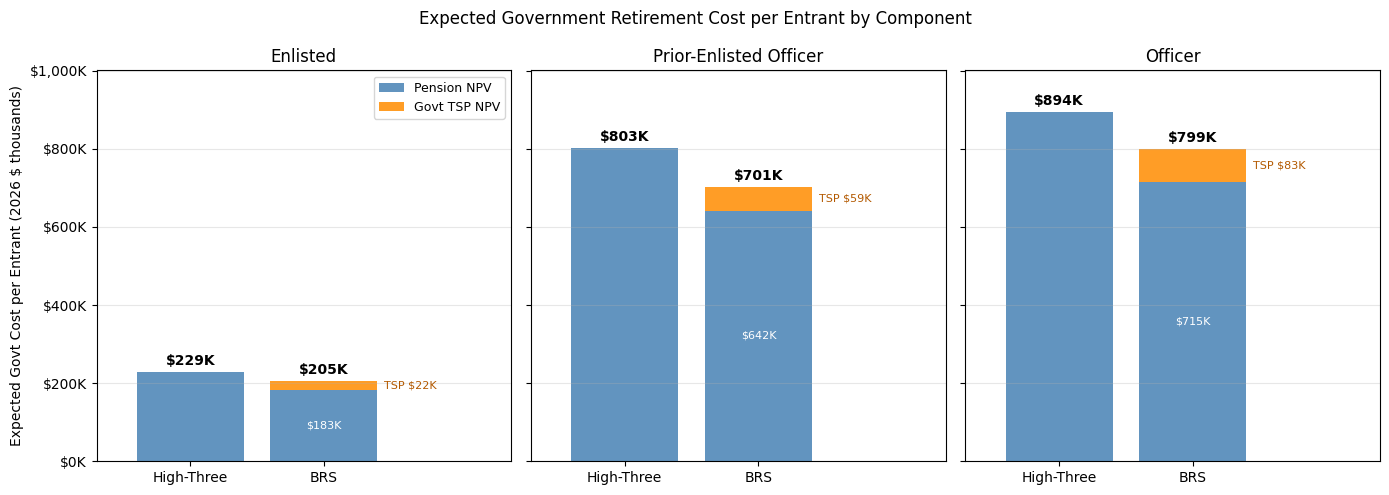

In [9]:
display_profiles = PROFILE_ORDER
fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

for ax, profile in zip(axes, display_profiles):
    row = expected.set_index("Profile").loc[profile]
    systems = ["High-Three", "BRS"]
    pension_vals = [
        row["H3_Expected"] / 1000,
        row["BRS_PensionExp"] / 1000,
    ]
    tsp_vals = [
        0.0,
        row["BRS_TSPExp"] / 1000,
    ]
    totals = [
        pension_vals[0],
        pension_vals[1] + tsp_vals[1],
    ]
    x = np.arange(len(systems))

    ax.bar(
        x,
        pension_vals,
        label="Pension NPV",
        color="steelblue",
        alpha=0.85,
    )
    ax.bar(
        x,
        tsp_vals,
        bottom=pension_vals,
        label="Govt TSP NPV",
        color="darkorange",
        alpha=0.85,
    )

    # totals above each bar
    for i in range(2):
        ax.annotate(
            f"${totals[i]:,.0f}K",
            xy=(i, totals[i]),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )
    # BRS components: pension inside, TSP beside segment
    ax.annotate(
        f"${pension_vals[1]:,.0f}K",
        xy=(1, pension_vals[1] / 2),
        ha="center",
        va="center",
        fontsize=8,
        color="white",
    )
    ax.annotate(
        f"TSP ${tsp_vals[1]:,.0f}K",
        xy=(1.45, pension_vals[1] + tsp_vals[1] / 2),
        ha="left",
        va="center",
        fontsize=8,
        color="#B35900",
    )

    ax.set_xlim(-0.7, 2.4)
    ax.set_xticks(x)
    ax.set_xticklabels(systems)
    ax.set_title(profile_labels[profile])
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda v, _: f"${v:,.0f}K"
        )
    )
    ax.grid(axis="y", alpha=0.3)

ymax = expected["H3_Expected"].max() / 1000
axes[0].set_ylim(0, ymax * 1.12)
axes[0].legend(fontsize=9, loc="upper right")
axes[0].set_ylabel(
    "Expected Govt Cost per Entrant (2026 $ thousands)"
)
fig.suptitle(
    "Expected Government Retirement Cost per Entrant"
    " by Component",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## Retirement-eligible subpopulation

The overall per-entrant result mixes members who reach retirement
with those who do not. Separating the 20+ YOS subpopulation isolates
the per-retiree cost and the pension-vs-TSP trade-off for long-service
members specifically.

In [10]:
print(
    "Retention to 20 YOS (DoD actuarial table):"
)
officer_surv20 = wr.loc[
    wr["YOS"] == 19, "OfficerSurvival"
].values[0]
enlisted_surv20 = wr.loc[
    wr["YOS"] == 19, "EnlistedSurvival"
].values[0]
print(
    f"  Officer: {officer_surv20:.1%}"
    " reach YOS 20 (start 20th year)"
)
print(
    f"  Enlisted: {enlisted_surv20:.1%}"
    " reach YOS 20 (start 20th year)"
)

print()
print(
    "Govt cost per member retiring at exactly 20 YOS:"
)
for profile in ["Enlisted", "Officer"]:
    row = fiscal[
        (fiscal["Profile"] == profile)
        & (fiscal["SepYOS"] == 20)
    ].iloc[0]
    sv_k = row['DoD_Savings'] / 1000
    sv_sign = '+' if sv_k >= 0 else '-'
    print(
        f"  {profile}: "
        f"H3=${row['H3_GovtCost']/1000:,.1f}K  "
        f"BRS=${row['BRS_GovtCost']/1000:,.1f}K  "
        f"DoD saves {sv_sign}${abs(sv_k):,.1f}K"
    )

Retention to 20 YOS (DoD actuarial table):
  Officer: 41.2% reach YOS 20 (start 20th year)
  Enlisted: 18.8% reach YOS 20 (start 20th year)

Govt cost per member retiring at exactly 20 YOS:
  Enlisted: H3=$1,047.3K  BRS=$902.6K  DoD saves +$144.7K
  Officer: H3=$1,696.2K  BRS=$1,476.3K  DoD saves +$219.9K


### Where the spending goes: early separatees vs. retirees

Splitting expected per-entrant cost by who receives it —
E[cost] = P(sep < 20)·E[cost | sep < 20] +
P(20+)·E[cost | 20+] — shows that BRS barely changes the
*direction* of DoD's retirement spending. Under High-Three,
100% of spending goes to the minority who reach 20 YOS, by
construction; under BRS only ~2–4% reaches the ≤19 YOS
majority. The savings come from paying retirees less (12–14%
less per retiree), not from redistribution.

The pension cliff is also visible in government dollars:
serving the 20th year raises DoD's obligation by roughly
\$0.8–1.7M depending on profile and system — BRS softens
the cliff only modestly on the cost side.

**Caveat:** these are DoD actuarial costs. The member-side
*value* of the early-separatee TSP benefit is roughly twice
the government's cost (market growth to age 60 — see the
actuarial-vs-entitlement table above), so the cost share
understates the benefit share from the member's perspective.


In [11]:
print(
    "Where DoD's expected retirement spending goes"
    " (2026 $):"
)
print(
    f"  {'Profile':22} {'Sys':4} {'E[cost]':>9}"
    f" {'to <20':>8} {'share':>6}"
    f" {'per early':>10} {'per retiree':>12}"
)
print("  " + "-" * 78)
for profile in PROFILE_ORDER:
    w = scenario_weights[profile]
    sub = (
        fiscal[fiscal["Profile"] == profile]
        .set_index("SepYOS")
        .reindex(w.index)
    )
    early = w.index < 20
    p_early = float(w[early].sum())
    p20 = 1.0 - p_early
    for col, name in [
        ("H3_GovtCost", "H3"),
        ("BRS_GovtCost", "BRS"),
    ]:
        tot = float((w * sub[col]).sum())
        to_e = float(
            (w[early] * sub[col][early]).sum()
        )
        to_l = tot - to_e
        print(
            f"  {profile:22} {name:4}"
            f" {tot / 1000:>8,.1f}K"
            f" {to_e / 1000:>7,.1f}K"
            f" {to_e / tot:>6.1%}"
            f" {to_e / p_early / 1000:>9,.1f}K"
            f" {to_l / p20 / 1000:>11,.1f}K"
        )

print()
print(
    "Marginal cost of the 20th year"
    " (govt obligation at 18 vs 20 YOS):"
)
for profile in PROFILE_ORDER:
    sub = fiscal[fiscal["Profile"] == profile]
    c18 = sub[sub["SepYOS"] == 18].iloc[0]
    c20 = sub[sub["SepYOS"] == 20].iloc[0]
    print(
        f"  {profile:22}"
        f" H3 ${c18['H3_GovtCost'] / 1000:>5,.0f}K"
        f" -> ${c20['H3_GovtCost'] / 1000:>7,.0f}K;"
        f"  BRS ${c18['BRS_GovtCost'] / 1000:>5,.0f}K"
        f" -> ${c20['BRS_GovtCost'] / 1000:>7,.0f}K"
    )


Where DoD's expected retirement spending goes (2026 $):
  Profile                Sys    E[cost]   to <20  share  per early  per retiree
  ------------------------------------------------------------------------------
  Enlisted               H3      228.8K     0.0K   0.0%       0.0K     1,219.6K
  Enlisted               BRS     204.8K     7.3K   3.6%       9.0K     1,052.4K
  PriorEnlistedOfficer   H3      802.6K     0.0K   0.0%       0.0K     1,950.3K
  PriorEnlistedOfficer   BRS     701.4K     9.1K   1.3%      15.5K     1,682.3K
  Officer                H3      893.9K     0.0K   0.0%       0.0K     2,172.2K
  Officer                BRS     798.6K    16.0K   2.0%      27.1K     1,901.8K

Marginal cost of the 20th year (govt obligation at 18 vs 20 YOS):
  Enlisted               H3 $    0K -> $  1,047K;  BRS $   54K -> $    903K
  PriorEnlistedOfficer   H3 $    0K -> $  1,601K;  BRS $   71K -> $  1,368K
  Officer                H3 $    0K -> $  1,696K;  BRS $  101K -> $  1,476K


## Monte Carlo uncertainty — pension component

The deterministic analysis uses fixed COLA / pay growth (2.75%)
and life expectancy (SSA 2022 male median). In the MC, the COLA
draw drives basic-pay growth, the pension COLA, and the 2026-\$
deflator, so every component — including `GovtTSP_PV` — varies
across iterations.

**Methodology:**
- N = 20,000 iterations
- COLA: one draw per iteration, **shared across all scenarios**
  (Normal fit on rolling 30-year average CPI, matching 03b;
  floored at 0 — the draw represents lifetime-average
  inflation, held constant within an iteration)
- Pay growth: basic pay grows at the iteration's COLA draw, so
  the High-Three base and govt TSP contributions are stochastic
- Death age: independent draw per scenario per iteration
  (Normal(MaleTotalAge[sep_age], σ = 13.0), clipped at sep_age)
- All values deflated to constant 2026 dollars
- Per-entrant savings: separation-weighted sum computed
  **inside** each iteration, preserving cross-scenario COLA
  correlation


In [12]:
from monte_carlo import (  # noqa: E402
    DEATH_AGE_STD,
    fit_cola_stats,
    govt_tsp_pv_vec,
    high3_base_vec,
    npv_pension_vec,
)

N_ITER = 20_000
# COLA draw = lifetime-average inflation; rolling-average
# fit matches the 03b parameterization
COLA_WINDOW = 30

cpi = pd.read_csv(PROCESSED / "cpi_inflation.csv")
life_exp = pd.read_csv(PROCESSED / "life_expectancy.csv")
cola_params = fit_cola_stats(cpi, window=COLA_WINDOW)

print(
    f"COLA: mean={cola_params['mean']:.2%}"
    f"  std={cola_params['std']:.2%}"
    f"  (rolling {COLA_WINDOW}-yr avg CPI)"
)
print("Deterministic baseline (DoD actuarial): 2.75%")
print(f"Death age std: {DEATH_AGE_STD:.1f} years")
print(f"MC iterations: {N_ITER:,}")


COLA: mean=3.39%  std=1.27%  (rolling 30-yr avg CPI)
Deterministic baseline (DoD actuarial): 2.75%
Death age std: 13.0 years
MC iterations: 20,000


In [13]:
rng = np.random.default_rng(42)

# One COLA draw per iteration, shared across scenarios;
# drives pay growth, pension COLA, and the 2026-$ deflator
cola_v = np.maximum(
    rng.normal(
        cola_params["mean"], cola_params["std"], N_ITER
    ),
    0.0,
)


def pay_series(profile, sep_yos):
    """2026-table monthly pay through sep_yos."""
    return (
        pay.query(
            "Profile == @profile and YOS <= @sep_yos"
        )
        .set_index("YOS")["MonthlyPay"]
    )


# Per-scenario DoD savings arrays (constant 2026 $)
scenario_savings = {}
for _, row in fiscal.iterrows():
    prof = row["Profile"]
    sep_yos = int(row["SepYOS"])
    sep_age = int(row["SepAge"])
    p_ser = pay_series(prof, sep_yos)
    defl_v = (1.0 + cola_v) ** sep_yos
    govt_tsp_v = govt_tsp_pv_vec(
        p_ser, cola_v, sep_yos, DISCOUNT_RATE
    )
    if sep_yos >= 20:
        base_v = high3_base_vec(p_ser, cola_v)
        h3_ann_v = base_v * 12.0 * 0.025 * sep_yos
        brs_ann_v = base_v * 12.0 * 0.020 * sep_yos
        le_row = life_exp.loc[
            life_exp["Age"] == sep_age
        ].iloc[0]
        mean_death = float(le_row["MaleTotalAge"])
        death_v = np.clip(
            rng.normal(
                mean_death, DEATH_AGE_STD, N_ITER
            ),
            float(sep_age), 120.0,
        )
        n_pens_v = death_v - float(sep_age)
        h3_v = npv_pension_vec(
            h3_ann_v, cola_v, DISCOUNT_RATE, n_pens_v
        )
        brs_v = npv_pension_vec(
            brs_ann_v, cola_v, DISCOUNT_RATE, n_pens_v
        )
        savings_v = (h3_v - brs_v - govt_tsp_v) / defl_v
    else:
        savings_v = -govt_tsp_v / defl_v
    scenario_savings[(prof, sep_yos)] = savings_v

# Separation-weighted per-entrant savings distribution# Separation-weighted per-entrant savings distribution
pe_savings = {}
for profile in PROFILE_ORDER:
    w = scenario_weights[profile]
    weighted_v = np.zeros(N_ITER)
    for sep_yos_key, weight in w.items():
        weighted_v += (
            weight
            * scenario_savings[(profile, sep_yos_key)]
        )
    pe_savings[profile] = weighted_v

print(
    "Per-entrant DoD savings distribution"
    " (2026 $ thousands):"
)
print(
    f"  {'Profile':20} {'p10':>8} {'p25':>8}"
    f" {'p50':>8} {'p75':>8} {'p90':>8} {'mean':>8}"
)
print("  " + "-" * 74)
def _vfmt(x):
    s = '' if x >= 0 else '-'
    return f"{s + '$' + format(abs(x), ',.1f'):>8}"


for profile, sv in pe_savings.items():
    pcts = np.percentile(sv, [10, 25, 50, 75, 90])
    vals = [_vfmt(v / 1000) for v in pcts]
    mean_s = _vfmt(sv.mean() / 1000)
    print(
        f"  {profile:20} "
        + " ".join(vals)
        + " " + mean_s
    )


Per-entrant DoD savings distribution (2026 $ thousands):
  Profile                   p10      p25      p50      p75      p90     mean
  --------------------------------------------------------------------------
  Enlisted                $13.0    $19.2    $27.2    $37.1    $48.4    $29.4
  PriorEnlistedOfficer    $66.0    $85.3   $111.3   $142.8   $178.5   $118.0
  Officer                 $52.9    $76.0   $105.6   $140.5   $178.6   $111.9


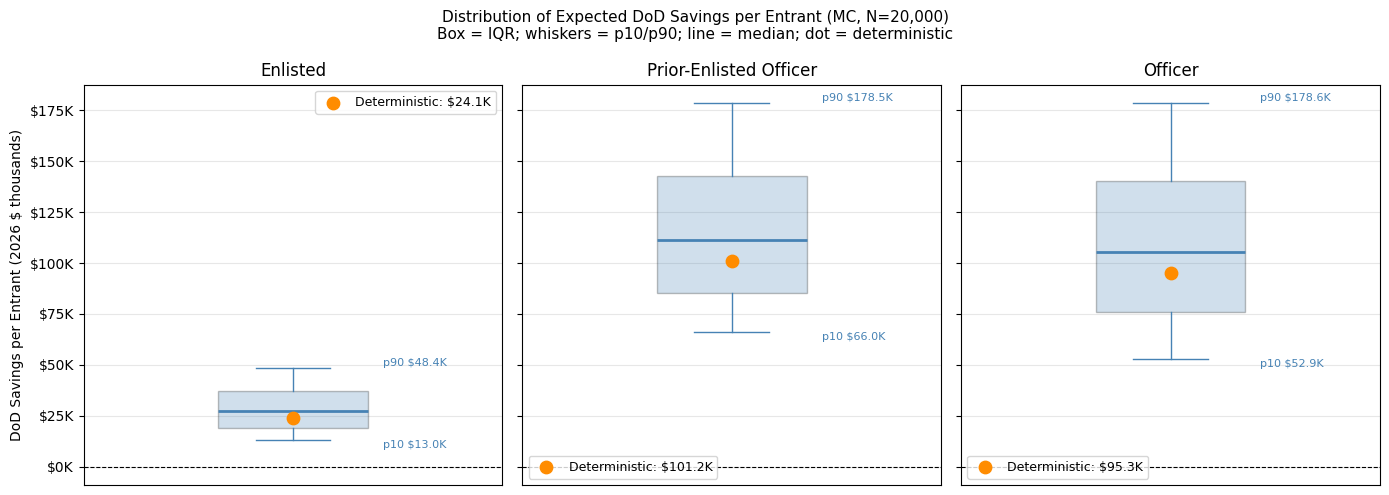

In [14]:
plot_profiles = PROFILE_ORDER
fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

for ax, profile in zip(axes, plot_profiles):
    sv = pe_savings[profile] / 1000
    det_val = (
        expected
        .set_index("Profile")
        .loc[profile, "Savings_PerEntrant"] / 1000
    )
    p10, p50, p90 = np.percentile(sv, [10, 50, 90])

    bp = ax.boxplot(
        sv,
        positions=[0],
        widths=0.5,
        whis=[10, 90],
        showfliers=False,
        patch_artist=True,
        medianprops={
            "color": "steelblue", "linewidth": 2
        },
        boxprops={
            "facecolor": "steelblue", "alpha": 0.25
        },
        whiskerprops={"color": "steelblue"},
        capprops={"color": "steelblue"},
    )
    ax.scatter(
        0, det_val,
        color="darkorange", zorder=5, s=80,
        label=f"Deterministic: ${det_val:,.1f}K",
    )
    ax.axhline(
        0, color="black", linewidth=0.8,
        linestyle="--",
    )
    ax.set_xlim(-0.7, 0.7)
    ax.set_xticks([])
    ax.set_title(profile_labels[profile])
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda v, _: f"${v:,.0f}K"
        )
    )
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    for val, label, va in [
        (p90, f"p90 ${p90:,.1f}K", "bottom"),
        (p10, f"p10 ${p10:,.1f}K", "top"),
    ]:
        ax.annotate(
            label,
            xy=(0.3, val),
            fontsize=8,
            color="steelblue",
            va=va,
        )

axes[0].set_ylabel(
    "DoD Savings per Entrant (2026 $ thousands)"
)
fig.suptitle(
    "Distribution of Expected DoD Savings per Entrant"
    " (MC, N=20,000)\n"
    "Box = IQR; whiskers = p10/p90;"
    " line = median; dot = deterministic",
    fontsize=11,
)
plt.tight_layout()
plt.show()


In [15]:
# PEOs enter as enlisted accessions and are already
# counted in this split; a separate PEO line would
# double-count (see Force-level cost projection note)
accession_map = {
    "Enlisted": ENLISTED_ACCESSIONS,
    "Officer": OFFICER_ACCESSIONS,
}

print(
    "Force-level savings with MC uncertainty"
    " (2026 $ millions, per annual accession cohort):"
)
print(
    f"  {'Profile':12} {'N':>10}"
    f" {'p10':>10} {'p50':>10} {'p90':>10}"
    f" {'Det.':>10}"
)
print("  " + "-" * 64)
mc_agg_tot = {"p10": 0.0, "p50": 0.0,
              "p90": 0.0, "det": 0.0}


def _sfmt(v):
    """Format 2026 $ millions with explicit sign."""
    s = '+' if v >= 0 else '-'
    return f"{s + '$' + format(abs(v), ',.1f'):>10}"


for profile, n in accession_map.items():
    sv = pe_savings[profile]
    p10_m = n * np.percentile(sv, 10) / 1e6
    p50_m = n * np.percentile(sv, 50) / 1e6
    p90_m = n * np.percentile(sv, 90) / 1e6
    det_m = (
        n
        * expected
        .set_index("Profile")
        .loc[profile, "Savings_PerEntrant"]
        / 1e6
    )
    for k, v in zip(
        ["p10", "p50", "p90", "det"],
        [p10_m, p50_m, p90_m, det_m],
    ):
        mc_agg_tot[k] += v
    print(
        f"  {profile:12} {n:>10,}"
        f" {_sfmt(p10_m)} {_sfmt(p50_m)}"
        f" {_sfmt(p90_m)} {_sfmt(det_m)}"
    )
print("  " + "-" * 64)
tot_n = OFFICER_ACCESSIONS + ENLISTED_ACCESSIONS
t = mc_agg_tot
print(
    f"  {'Total':12} {tot_n:>10,}"
    f" {_sfmt(t['p10'])} {_sfmt(t['p50'])}"
    f" {_sfmt(t['p90'])} {_sfmt(t['det'])}"
)


Force-level savings with MC uncertainty (2026 $ millions, per annual accession cohort):
  Profile               N        p10        p50        p90       Det.
  ----------------------------------------------------------------
  Enlisted        140,000  +$1,826.4  +$3,803.6  +$6,774.5  +$3,371.6
  Officer          18,000    +$952.7  +$1,900.1  +$3,214.3  +$1,716.3
  ----------------------------------------------------------------
  Total           158,000  +$2,779.1  +$5,703.7  +$9,988.8  +$5,087.8


## Convergence check — Officer per-entrant savings

Verify 20,000 iterations is sufficient by comparing
statistics at N=20K vs N=40K, using the same seed.
Officer is the most volatile profile (largest pension
values and widest spread). Same 1% threshold as 03b.


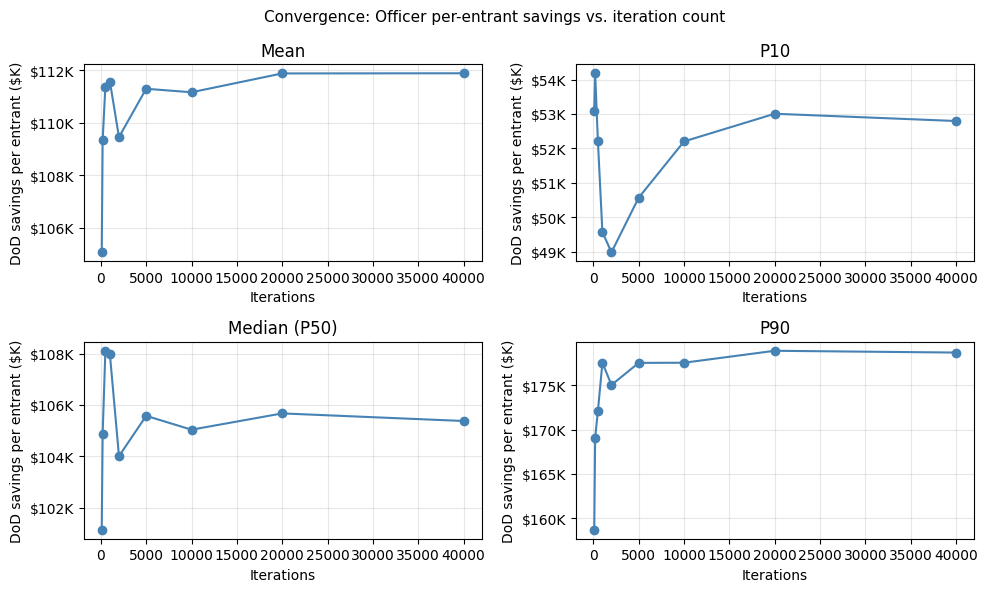

In [16]:
N_CONV = 40_000
rng_cv = np.random.default_rng(42)

cola_cv = np.maximum(
    rng_cv.normal(
        cola_params["mean"], cola_params["std"],
        N_CONV,
    ),
    0.0,
)

# Officer only - the metric under test
sv_cv = {}
for _, row in fiscal[
    fiscal["Profile"] == "Officer"
].iterrows():
    sep_yos = int(row["SepYOS"])
    sep_age = int(row["SepAge"])
    p_ser = pay_series("Officer", sep_yos)
    defl = (1.0 + cola_cv) ** sep_yos
    g_v = govt_tsp_pv_vec(
        p_ser, cola_cv, sep_yos, DISCOUNT_RATE
    )
    if sep_yos >= 20:
        base_v = high3_base_vec(p_ser, cola_cv)
        h3_ann_v = base_v * 12.0 * 0.025 * sep_yos
        brs_ann_v = base_v * 12.0 * 0.020 * sep_yos
        le_row = life_exp.loc[
            life_exp["Age"] == sep_age
        ].iloc[0]
        mean_d = float(le_row["MaleTotalAge"])
        d_cv = np.clip(
            rng_cv.normal(
                mean_d, DEATH_AGE_STD, N_CONV
            ),
            float(sep_age), 120.0,
        )
        n_pv = d_cv - float(sep_age)
        h3v = npv_pension_vec(
            h3_ann_v, cola_cv, DISCOUNT_RATE, n_pv
        )
        brsv = npv_pension_vec(
            brs_ann_v, cola_cv, DISCOUNT_RATE, n_pv
        )
        sv_cv[sep_yos] = (h3v - brsv - g_v) / defl
    else:
        sv_cv[sep_yos] = -g_v / defl

w_cv = scenario_weights["Officer"]
pe_cv = np.zeros(N_CONV)
for sep_yos_key, weight in w_cv.items():
    pe_cv += weight * sv_cv[sep_yos_key]

checkpoints = [
    100, 200, 500, 1_000, 2_000,
    5_000, 10_000, 20_000, 40_000,
]
conv_stats = {}
for n in checkpoints:
    sub = pe_cv[:n] / 1000
    conv_stats[n] = {
        "mean": float(sub.mean()),
        "p10": float(np.percentile(sub, 10)),
        "p50": float(np.percentile(sub, 50)),
        "p90": float(np.percentile(sub, 90)),
    }

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
stat_keys = ["mean", "p10", "p50", "p90"]
titles = ["Mean", "P10", "Median (P50)", "P90"]
for ax, lbl, ttl in zip(
    axes.flat, stat_keys, titles
):
    ys = [conv_stats[n][lbl] for n in checkpoints]
    ax.plot(
        checkpoints, ys, "o-", color="steelblue"
    )
    ax.set_title(ttl)
    ax.set_xlabel("Iterations")
    ax.set_ylabel(
        "DoD savings per entrant ($K)"
    )
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _: f"${x:,.0f}K"
        )
    )
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Convergence: Officer per-entrant savings"
    " vs. iteration count",
    fontsize=11,
)
plt.tight_layout()
plt.show()


In [17]:
THRESHOLD_PCT = 1.0

spread_40k = (
    np.percentile(pe_cv, 90)
    - np.percentile(pe_cv, 10)
) / 1000

pct_map = {"p10": 10, "p50": 50, "p90": 90}
labels = {
    "p10": "P10", "p50": "Median",
    "mean": "Mean", "p90": "P90",
}


def _stat(arr, k):
    if k == "mean":
        return float(arr.mean()) / 1000
    return (
        float(np.percentile(arr, pct_map[k])) / 1000
    )


print(
    "Half-to-full stability"
    " (Officer per-entrant savings):"
)
print(
    f"P10-P90 spread at N=40K: ${spread_40k:,.1f}K"
)
print()
print(
    f"  {'Stat':>7}  {'N=20K ($K)':>11}"
    f"  {'N=40K ($K)':>11}  {'Shift ($K)':>10}"
    f"  {'% spread':>9}"
)
print("  " + "-" * 58)
shifts = {}
for c in ["p10", "p50", "mean", "p90"]:
    v20 = _stat(pe_cv[:20_000], c)
    v40 = _stat(pe_cv, c)
    delta = v40 - v20
    pct = abs(delta) / spread_40k * 100
    shifts[c] = pct
    print(
        f"  {labels[c]:>7}  {v20:>+11.1f}"
        f"  {v40:>+11.1f}  {delta:>+10.1f}"
        f"  {pct:>8.2f}%"
    )

max_pct = max(shifts.values())
worst = labels[max(shifts, key=shifts.get)]
verdict = "PASS" if max_pct < THRESHOLD_PCT else "FAIL"
print()
print(
    f"Max shift 20K\u219240K: {max_pct:.2f}% of spread"
    f" (on {worst})"
)
print(
    f"Stability verdict: {verdict}"
    f" \u2014 threshold {THRESHOLD_PCT:.0f}%"
)


Half-to-full stability (Officer per-entrant savings):
P10-P90 spread at N=40K: $125.9K

     Stat   N=20K ($K)   N=40K ($K)  Shift ($K)   % spread
  ----------------------------------------------------------
      P10        +53.0        +52.8        -0.2      0.17%
   Median       +105.7       +105.4        -0.3      0.23%
     Mean       +111.9       +111.9        +0.0      0.00%
      P90       +178.9       +178.7        -0.2      0.16%

Max shift 20K→40K: 0.23% of spread (on Median)
Stability verdict: PASS — threshold 1%


## Force-level cost projection

Multiplying per-entrant expected costs by annual accession volume
estimates the retirement liability accrued for one year's cohort of
new entrants — the annual "normal cost" addition to the DoD retirement
obligation.

**Prior-enlisted officers are intentionally excluded** from
force-level scaling: they enter service as enlisted
accessions and later commission, so the officer + enlisted
accession split already covers them — a separate PEO line
would double-count.

**Accession figures** are approximate; the sensitivity section below
shows how the aggregate changes at different force sizes.

In [18]:
agg_rows = []
for profile, n in accession_map.items():
    row = expected.set_index("Profile").loc[profile]
    h3_agg = n * row["H3_Expected"]
    brs_agg = n * row["BRS_Expected"]
    savings_agg = h3_agg - brs_agg
    agg_rows.append({
        "Profile": profile,
        "Accessions": n,
        "H3_Obligation_M": h3_agg / 1e6,
        "BRS_Obligation_M": brs_agg / 1e6,
        "Savings_M": savings_agg / 1e6,
    })

agg = pd.DataFrame(agg_rows)

totals = agg[
    ["H3_Obligation_M", "BRS_Obligation_M", "Savings_M"]
].sum()

print(
    f"Annual accessions: "
    f"{OFFICER_ACCESSIONS:,} officers, "
    f"{ENLISTED_ACCESSIONS:,} enlisted"
)
print()
print(
    "Annual retirement obligation accrual"
    " (2026 $ millions, per cohort of new entrants):"
)
print(
    f"  {'Profile':12} {'Accessions':>12}"
    f" {'H3 ($M)':>10} {'BRS ($M)':>10}"
    f" {'Savings ($M)':>14}"
)
print("  " + "-" * 62)
for _, row in agg.iterrows():
    sign = "+" if row["Savings_M"] >= 0 else "-"
    print(
        f"  {row['Profile']:12}"
        f" {row['Accessions']:>12,}"
        f" {'$' + format(row['H3_Obligation_M'], ',.1f'):>10}"
        f" {'$' + format(row['BRS_Obligation_M'], ',.1f'):>10}"
        f" {sign + '$' + format(abs(row['Savings_M']), ',.1f'):>14}"
    )
print("  " + "-" * 62)
sign_tot = "+" if totals["Savings_M"] >= 0 else "-"
print(
    f"  {'Total':12}"
    f" {OFFICER_ACCESSIONS + ENLISTED_ACCESSIONS:>12,}"
    f" {'$' + format(totals['H3_Obligation_M'], ',.1f'):>10}"
    f" {'$' + format(totals['BRS_Obligation_M'], ',.1f'):>10}"
    f" {sign_tot + '$' + format(abs(totals['Savings_M']), ',.1f'):>14}"
)

Annual accessions: 18,000 officers, 140,000 enlisted

Annual retirement obligation accrual (2026 $ millions, per cohort of new entrants):
  Profile        Accessions    H3 ($M)   BRS ($M)   Savings ($M)
  --------------------------------------------------------------
  Enlisted          140,000  $32,038.4  $28,666.8      +$3,371.6
  Officer            18,000  $16,091.0  $14,374.7      +$1,716.3
  --------------------------------------------------------------
  Total             158,000  $48,129.4  $43,041.5      +$5,087.8


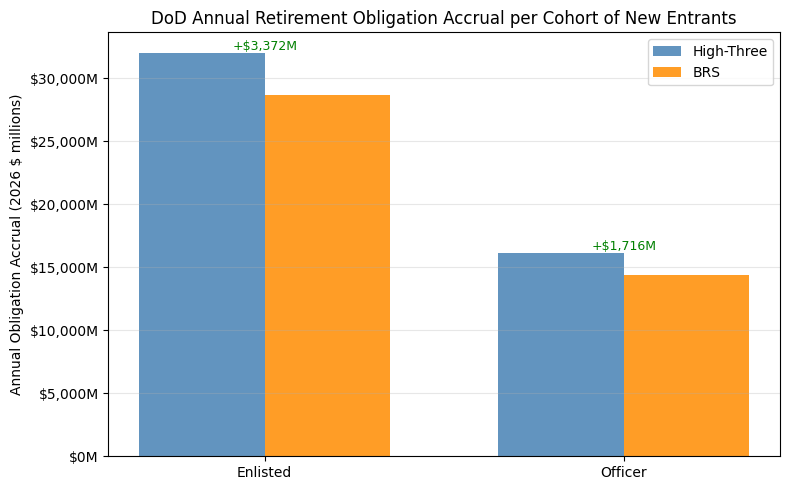


Annotations show H3 − BRS difference per profile. Positive = BRS cheaper; negative = BRS costs more.


In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(agg))
bar_w = 0.35
ax.bar(
    x - bar_w / 2,
    agg["H3_Obligation_M"],
    width=bar_w,
    label="High-Three",
    color="steelblue",
    alpha=0.85,
)
ax.bar(
    x + bar_w / 2,
    agg["BRS_Obligation_M"],
    width=bar_w,
    label="BRS",
    color="darkorange",
    alpha=0.85,
)

for i, row in agg.iterrows():
    diff = row["Savings_M"]
    sign = "+" if diff >= 0 else ""
    ax.annotate(
        f"{sign}${diff:,.0f}M",
        xy=(i, max(
            row["H3_Obligation_M"],
            row["BRS_Obligation_M"],
        )),
        ha="center",
        va="bottom",
        fontsize=9,
        color=(
            "green" if diff >= 0 else "crimson"
        ),
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [profile_labels[p] for p in agg["Profile"]]
)
ax.set_ylabel(
    "Annual Obligation Accrual (2026 $ millions)"
)
ax.set_title(
    "DoD Annual Retirement Obligation Accrual"
    " per Cohort of New Entrants"
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:,.0f}M")
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "\nAnnotations show H3 − BRS difference per profile."
    " Positive = BRS cheaper; negative = BRS costs more."
)

## Sensitivity: cost vs. accession size

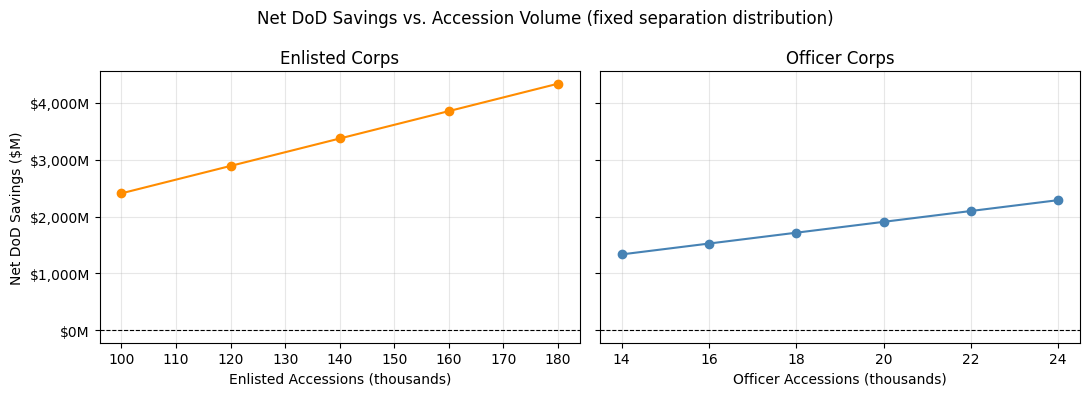

In [20]:
officer_range = np.arange(14_000, 24_001, 2_000)
enlisted_range = np.arange(100_000, 181_000, 20_000)

o_savings_per = (
    expected.set_index("Profile")
    .loc["Officer", "Savings_PerEntrant"]
)
e_savings_per = (
    expected.set_index("Profile")
    .loc["Enlisted", "Savings_PerEntrant"]
)

fig, axes = plt.subplots(
    1, 2, figsize=(11, 4), sharey=True
)

axes[0].plot(
    enlisted_range / 1000,
    enlisted_range * e_savings_per / 1e6,
    marker="o",
    color="darkorange",
)
axes[0].axhline(0, color="black", linewidth=0.8,
                linestyle="--")
axes[0].set_xlabel("Enlisted Accessions (thousands)")
axes[0].set_ylabel("Net DoD Savings ($M)")
axes[0].set_title("Enlisted Corps")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:,.0f}M")
)
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    officer_range / 1000,
    officer_range * o_savings_per / 1e6,
    marker="o",
    color="steelblue",
)
axes[1].axhline(0, color="black", linewidth=0.8,
                linestyle="--")
axes[1].set_xlabel("Officer Accessions (thousands)")
axes[1].set_title("Officer Corps")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:,.0f}M")
)
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    "Net DoD Savings vs. Accession Volume"
    " (fixed separation distribution)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Key findings

**Deterministic center-path:**
At 2.75% COLA / pay growth and median life expectancy, BRS
saves DoD 10–13% of H3 retirement cost per entrant
(\$95K/officer, \$24K/enlisted, \$101K/prior-enlisted officer,
constant 2026 \$). At the force level that is ~\$5.1 billion per
annual accession cohort (\$1.7B officer + \$3.4B enlisted).

**Monte Carlo uncertainty (COLA + life expectancy):**
The rolling 30-year average COLA mean (3.39%) exceeds the
2.75% actuarial assumption, lifting the MC median savings
above the deterministic estimate (\$106K vs \$95K/officer; \$27K
vs \$24K/enlisted). The p10–p90 range spans \$53K to
\$179K/officer and \$13K to \$48K/enlisted per entrant — savings
stay comfortably positive across the entire range for all
three profiles. At the force level the combined cohort savings
run from +\$2.8B (p10) to +\$10.0B (p90) with a median of
+\$5.7B. Because the COLA draw represents lifetime-average
inflation (rolling 30-year fit, std 1.27%) rather than annual
volatility, these bands honestly reflect long-horizon
uncertainty without overstating it.

**Interpretation note:**
Separation behavior is held fixed at historical DoD actuarial
rates. BRS makes early separation more attractive, so actual
rates may shift toward more early separatees, slightly reducing
DoD savings. Behavioral retention effects are out of scope
(see CLAUDE.md).


## Save output

In [21]:
out_cols = [
    "Profile", "SepYOS", "SepAge",
    "H3_GovtCost", "GovtTSP_PV",
    "BRS_GovtCost", "DoD_Savings",
]
out_path = PROCESSED / "fiscal_results.csv"
fiscal[out_cols].to_csv(out_path, index=False)
print(
    f"Saved: {out_path.name}"
    f"  ({out_path.stat().st_size / 1024:.1f} KB)"
)

# Persist separation weights so nb05 can reuse them
# without re-deriving the binning logic
weights_out = pd.concat(
    [
        w.rename("Weight")
        .rename_axis("SepYOS")
        .reset_index()
        .assign(Profile=profile)
        for profile, w in scenario_weights.items()
    ],
    ignore_index=True,
)[["Profile", "SepYOS", "Weight"]]
w_path = PROCESSED / "scenario_weights.csv"
weights_out.to_csv(w_path, index=False)
print(
    f"Saved: {w_path.name}"
    f"  ({w_path.stat().st_size / 1024:.1f} KB)"
)

print()
print(
    "Summary — expected DoD savings per entrant"
    " (+ = BRS costs less):"
)
for _, row in expected.iterrows():
    sign = "+" if row["Savings_PerEntrant"] >= 0 else ""
    pct_str = (
        f"{sign}{row['Savings_Pct']:.1%}"
        if not np.isnan(row["Savings_Pct"])
        else "N/A"
    )
    print(
        f"  {row['Profile']:30}"
        f" {sign}${row['Savings_PerEntrant']:,.0f}"
        f"  ({pct_str} of H3 cost)"
    )

Saved: fiscal_results.csv  (4.5 KB)
Saved: scenario_weights.csv  (1.8 KB)

Summary — expected DoD savings per entrant (+ = BRS costs less):
  Enlisted                       +$24,083  (+10.5% of H3 cost)
  PriorEnlistedOfficer           +$101,190  (+12.6% of H3 cost)
  Officer                        +$95,349  (+10.7% of H3 cost)
